In [ ]:
# Colab necessary packages installation
# !pip install torch_geometric
# !apt install libgraphviz-dev
# !pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
# Colab import google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# imports
import torch
import json
import pandas as pd
from torch_geometric.data.hetero_data import HeteroData
from torch_geometric.loader import DataLoader
from torch.nn import ModuleList, Module, Linear, ModuleDict
from torch_geometric.nn import HeteroConv, GATv2Conv, global_mean_pool
from typing_extensions import Self

In [ ]:
# Default vars
DATASET         = "bpi_2013"

ROOT_PATH       = "drive/MyDrive/Thesis"
PROCESSED_PATH  = f"{ROOT_PATH}/data/datasets/processed/{DATASET}"
MODEL_PATH      = f"{ROOT_PATH}/data/datasets/models/{DATASET}"
GRAPHS_PATH     = f"{ROOT_PATH}/data/datasets/graphs/{DATASET}"
MIN_PREFIX_LEN  = 2
BATCH_SIZE      = 128

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

config = {
    "hid": 128,
    "layers": 2,
    "aggregation": "max",
}

In [ ]:
# Set up
with open(f"{ROOT_PATH}/data/dataset_features.json") as f:
    dataset_info = json.load(f)[DATASET]

tab_all = pd.read_csv(f"{PROCESSED_PATH}/{DATASET}_processed_all.csv")

categorical_columns = dataset_info["categorical"]
categorical_columns = [col for col in categorical_columns if col in tab_all.columns]
real_value_columns = dataset_info["numerical"]

list_unique = {k : list(tab_all[k].unique()) for k in categorical_columns}

idx_to_activity = {i: name for i, name in enumerate(list_unique["Activity"])} # Index-activity map

In [ ]:
# Model definition (SEPHIGRAPH)
class HGNN(Module):
    def __init__(self, output_cat, output_real, nodes_relations, parameters) -> Self:
        super().__init__()
        hid         = parameters["hid"]
        layers      = parameters["layers"]
        aggregation = parameters["aggregation"]
        self.output_cat  = output_cat
        self.output_real = output_real
        self.convs = ModuleList()
        for _ in range(layers):
            conv = HeteroConv(
                {
                    relation: GATv2Conv(
                        (-1, -1), hid, 1, False,
                        add_self_loops=False, residual=False
                    )
                    for relation in nodes_relations
                },
                aggr=aggregation,
            )
            self.convs.append(conv)
        self.FC = ModuleDict()
        for k in output_cat:
            self.FC[k] = Linear(hid, output_cat[k])
        for k in output_real:
            self.FC[k] = Linear(hid, 1)

    def forward(self, batch):
        for conv in self.convs:
            batch.x_dict = conv(batch.x_dict, batch.edge_index_dict)
            batch.x_dict = {k: x.relu() for k, x in batch.x_dict.items()}
        output = {}
        for k in self.output_cat:
            output[k] = global_mean_pool(batch.x_dict[k], batch[k].batch)
            output[k] = self.FC[k](output[k])
        for k in self.output_real:
            output[k] = global_mean_pool(batch.x_dict[k], batch[k].batch)
            output[k] = self.FC[k](output[k]).reshape(1, -1)[0]
        return output

In [ ]:
# Test prefixes load
torch.serialization.add_safe_globals([HeteroData]) # "marks the HeteroData class as safe for weights_only loading in torch.load"
X_TEST_FULL = torch.load(
    f"{GRAPHS_PATH}/test_set.pt",
    weights_only=False,
    map_location=device
)

X_TEST = [
    (g,t) for g, t in X_TEST_FULL
]

print(f"Grafi nel test set totale:   {len(X_TEST_FULL)}")

Grafi nel test set totale:   139


In [ ]:
# Get edge_types
edge_types = set()
for g, t in X_TEST:
    _, et = g.metadata()
    edge_types.update(et)
EDGE_TYPES = list(edge_types)

outputcat  = {k: len(list_unique[k]) for k in categorical_columns if k in ("Activity", "org:resource")}
outputreal = [k for k in real_value_columns if k == "time:timestamp"]

for k in outputcat:
    outputcat[k] += 1

print(outputcat)
print(outputreal)

{'Activity': 8, 'org:resource': 586}
['time:timestamp']


In [ ]:
# Define net model
net = HGNN(
    parameters=config,
    output_cat=outputcat,
    output_real=outputreal,
    nodes_relations=EDGE_TYPES,
)

net.load_state_dict(torch.load(f"{MODEL_PATH}/model.pt", map_location=device, weights_only=False), strict=False)
net = net.to(device)


In [ ]:
# First graph dissection
g, t = X_TEST[34]
print(g)

HeteroData(
  Activity={ x=[2, 8] },
  org:resource={ x=[2, 586] },
  time:timestamp={ x=[2, 1] },
  concept:name={ x=[2, 5] },
  impact={ x=[1, 5] },
  lifecycle:transition={ x=[2, 8] },
  org:group={ x=[2, 16] },
  org:role={ x=[2, 30] },
  organization country={ x=[1, 18] },
  organization involved={ x=[2, 325] },
  product={ x=[1, 338] },
  resource country={ x=[2, 22] },
  (Activity, followed_by, Activity)={ edge_index=[2, 2] },
  (Activity, related_to, org:resource)={ edge_index=[2, 2] },
  (Activity, related_to, time:timestamp)={ edge_index=[2, 2] },
  (Activity, related_to, concept:name)={ edge_index=[2, 2] },
  (Activity, related_to, impact)={ edge_index=[2, 2] },
  (Activity, related_to, lifecycle:transition)={ edge_index=[2, 2] },
  (Activity, related_to, org:group)={ edge_index=[2, 2] },
  (Activity, related_to, org:role)={ edge_index=[2, 2] },
  (Activity, related_to, organization country)={ edge_index=[2, 2] },
  (Activity, related_to, organization involved)={ edge_index=

In [ ]:
def print_edges(g):
  print("\nEdges List:")
  for (src_type, rel, dst_type), edge_store in g.edge_items():
      if rel.startswith("rev_"):
          continue
      print(f"({src_type}, {rel}, {dst_type})")
      print(edge_store.edge_index)
      print()

print_edges(g)


Edges List:
(Activity, followed_by, Activity)
tensor([[0, 1],
        [1, 0]])

(Activity, related_to, org:resource)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, time:timestamp)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, concept:name)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, impact)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, lifecycle:transition)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, org:group)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, org:role)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, organization country)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, organization involved)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, product)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, resource country)
tensor([[0, 1],
        [0, 1]])

(org:resource, related_to, org:resource)
tensor([[0, 1],
        [1, 0]])

(time:timestamp, related_to, time:timestamp)
tenso

In [ ]:
loader = DataLoader([g], batch_size=1)
batch = next(iter(loader))  # ora batch[k].batch esiste

net.eval()
with torch.no_grad():
    out = net(batch)

print(out)

{'Activity': tensor([[  6.0421,   9.2831,   0.5564, -17.3939,   6.4151,   3.6212,   1.8207,
         -16.3245]]), 'org:resource': tensor([[ 2.1525e+01, -5.0996e+00, -1.0475e+01, -9.0902e+00, -3.5001e+01,
         -1.0381e+01, -7.4868e+00, -2.5736e-02, -1.0619e+01,  1.2769e+00,
         -6.3635e+00, -3.2952e+00, -3.5863e+01, -1.6225e+01, -8.1243e+00,
         -8.5550e+00, -8.5832e+00, -3.5779e+00, -1.0771e+00, -1.6945e+01,
         -1.6453e-01, -4.9195e+00, -1.2012e+01, -1.1740e+01, -3.6912e+00,
         -1.6417e+00, -1.0852e+01, -1.7515e+00,  1.6851e+00, -3.5778e+01,
         -5.6946e+00, -7.0508e+00, -6.8250e+00, -2.6897e+00, -3.0081e+00,
         -5.6747e-01, -3.5560e+01, -8.8674e+00,  1.1525e+00,  1.3983e-01,
         -5.6541e+00, -5.2414e+00, -1.1302e+01, -9.9399e+00, -1.2585e+01,
         -5.1738e+00, -3.5286e+01, -1.1207e+01, -3.5341e+01, -1.5804e+01,
          1.2550e+00, -3.5110e+01, -3.6210e+01, -9.3677e+00, -1.0803e+01,
         -7.0560e+00, -1.0553e+01, -4.9504e+00,  4.4673e

In [ ]:
# Predictions extraction
preds = {}

# Categoriche → argmax → one-hot
for k in outputcat:
    idx = torch.argmax(torch.softmax(out[k], dim=1), dim=1).item()
    one_hot = torch.zeros(1, outputcat[k])
    one_hot[0, idx] = 1.0
    preds[k] = one_hot
    if idx < len(list_unique[k]): # Check if idx is within the bounds of list_unique
        print(f"{k}: {list_unique[k][idx]}")
    else:
        print(f"{k}: <END {idx}>") # Handle the extra category

# Numeriche → valore diretto
for k in outputreal:
    preds[k] = out[k].reshape(1, 1)
    print(f"{k}: {out[k].item():.4f}")

Activity: Accepted-In Progress
org:resource: Value 1
time:timestamp: 3.4441


In [ ]:
for k in preds:
    print(f"{k}: grafo={g[k].x.shape[1]}, pred={preds[k].shape[1]}")

Activity: grafo=8, pred=8
org:resource: grafo=586, pred=586
time:timestamp: grafo=1, pred=1


In [ ]:
predicted_types = set(outputcat.keys()) | set(outputreal)

predicted_types

{'Activity', 'org:resource', 'time:timestamp'}

In [ ]:
other_types = set(g.node_types) - predicted_types

other_types

{'concept:name',
 'impact',
 'lifecycle:transition',
 'org:group',
 'org:role',
 'organization country',
 'organization involved',
 'product',
 'resource country'}

In [ ]:
resource_types = {ntype for ntype in g.node_types if ntype.startswith("org:")}

resource_types

{'org:group', 'org:resource', 'org:role'}

In [ ]:
def to_onehot(logits, n_classes):
    idx = torch.argmax(torch.softmax(logits, dim=1), dim=1).item()
    oh = torch.zeros(1, n_classes)
    oh[0, idx] = 1.0
    return oh

def add_edge(g, rel, src, dst):
  new_e = torch.tensor([[src], [dst]])
  if hasattr(g[rel], 'edge_index') and g[rel].edge_index is not None:
      g[rel].edge_index = torch.cat([g[rel].edge_index, new_e], dim=1)
  else:
      g[rel].edge_index = new_e

def find_node_index(g, ntype, predicted_tensor):
    """Trova l'indice del nodo di tipo ntype che ha lo stesso argmax del tensore predetto."""
    argmax_pred = predicted_tensor.argmax().item()
    for i in range(g[ntype].x.shape[0]):
        if g[ntype].x[i].argmax().item() == argmax_pred:
            return i
    return None  # non trovato — non dovrebbe succedere

In [ ]:
print(g.edge_types)

[('Activity', 'followed_by', 'Activity'), ('Activity', 'related_to', 'org:resource'), ('Activity', 'related_to', 'time:timestamp'), ('Activity', 'related_to', 'concept:name'), ('Activity', 'related_to', 'impact'), ('Activity', 'related_to', 'lifecycle:transition'), ('Activity', 'related_to', 'org:group'), ('Activity', 'related_to', 'org:role'), ('Activity', 'related_to', 'organization country'), ('Activity', 'related_to', 'organization involved'), ('Activity', 'related_to', 'product'), ('Activity', 'related_to', 'resource country'), ('org:resource', 'related_to', 'org:resource'), ('time:timestamp', 'related_to', 'time:timestamp'), ('concept:name', 'related_to', 'concept:name'), ('lifecycle:transition', 'related_to', 'lifecycle:transition'), ('org:group', 'related_to', 'org:group'), ('org:role', 'related_to', 'org:role'), ('organization involved', 'related_to', 'organization involved'), ('resource country', 'related_to', 'resource country'), ('org:resource', 'rev_related_to', 'Activity'

In [ ]:
def append_predicted_event(g, out, outputcat, outputreal):

  old_idx = {}   # indici dei nodi a cui appendere l'output
  new_idx = {}   # indici dei nodi da appendere

  old_idx = {ntype: g[ntype].x.shape[0] - 1 for ntype in g.node_types}  # snapshot iniziale

  #print_edges(g)

  for k in outputcat:
      new_feat = to_onehot(out[k], outputcat[k])

      if k in resource_types:
          existing = find_node_index(g, k, new_feat)
          if existing is not None:
              new_idx[k] = existing  # riusato
          else:
              g[k].x = torch.cat([g[k].x, new_feat], dim=0)
              new_idx[k] = old_idx[k] + 1 # appena creato
      else:
          g[k].x = torch.cat([g[k].x, new_feat], dim=0)
          new_idx[k] = old_idx[k] + 1

  for k in outputreal:
      new_feat = out[k].reshape(1, 1)

      if k in resource_types:
          existing = find_node_index(g, k, new_feat)
          if existing is not None:
              new_idx[k] = existing  # riusato
          else:
              g[k].x = torch.cat([g[k].x, new_feat], dim=0)
              new_idx[k] = old_idx[k] + 1  # appena creato
      else:
          g[k].x = torch.cat([g[k].x, new_feat], dim=0)
          new_idx[k] = old_idx[k] + 1

  # --- ricava gli archi da aggiungere dalla struttura esistente ---
  for (src, rel, dst) in g.edge_types:

      # Concateno predizioni
      if src == dst and src in predicted_types:
          if new_idx[src] == old_idx[src] + 1:
              add_edge(g, (src, rel, dst), old_idx[src], new_idx[src])

      # Activity → attributo predetto
      elif src == "Activity" and dst in predicted_types:
          add_edge(g, (src, rel, dst), new_idx[src], new_idx[dst])

      # Activity → costante
      elif src == "Activity" and dst not in predicted_types:
          add_edge(g, (src, rel, dst), new_idx[src], 0)

  # print_edges(g)


  return g

In [ ]:
newg = append_predicted_event(g, out, outputcat, outputreal)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

import networkx as nx
import matplotlib.pyplot as plt

def get_row(ntype):
    if ntype == "Activity":
        return 1
    elif ntype == "time:timestamp":
        return 2
    elif ntype == "org:resource":
        return 3
    else:
        return 0

def drawer(g_original):
    g = g_original.clone()
    G = nx.Graph()

    node_id = {}
    node_label = {}
    node_color = {}
    edge_label = {}
    counter = 0

    type_colors = {
        ntype: plt.cm.tab10(i % 10)
        for i, ntype in enumerate(g.node_types)
    }

    import torch

    def format_features(x_row):
        t = torch.tensor(x_row) if not isinstance(x_row, torch.Tensor) else x_row
        # one-hot: un solo 1, resto 0
        if t.sum() == 1.0 and ((t == 0) | (t == 1)).all():
            return f"class={t.argmax().item()}"
        # scalare singolo
        if t.numel() == 1:
            v = t.item()
            return str(int(v)) if float(v).is_integer() else f"{v:.4f}"
        # vettore multi-feature
        parts = []
        for v in t.tolist():
            parts.append(str(int(v)) if float(v).is_integer() else f"{v:.3f}")
        return ", ".join(parts)

    for ntype in g.node_types:
        n = g[ntype].x.shape[0]
        for i in range(n):
            nid = counter
            node_id[(ntype, i)] = nid
            vals = g[ntype].x[i].tolist()
            vals_str = format_features(g[ntype].x[i])
            node_label[nid] = f"{ntype}[{i}]\n{vals_str}"
            node_color[nid] = type_colors[ntype]
            G.add_node(nid)
            counter += 1

    for (src_type, rel, dst_type) in g.edge_types:
        if rel.startswith("rev_"):
            continue
        edge_index = g[(src_type, rel, dst_type)].edge_index
        for j in range(edge_index.shape[1]):
            src = node_id[(src_type, edge_index[0, j].item())]
            dst = node_id[(dst_type, edge_index[1, j].item())]
            if src != dst:
                G.add_edge(src, dst)
                edge_label[(src, dst)] = rel

    # --- custom row layout ---
    row_counters = {0: 0, 1: 0, 2: 0, 3: 0}
    row_counts = {0: 0, 1: 0, 2: 0, 3: 0}
    for ntype in g.node_types:
        row_counts[get_row(ntype)] += g[ntype].x.shape[0]

    pos = {}
    for (ntype, i), nid in node_id.items():
        row = get_row(ntype)
        col = row_counters[row]
        total = row_counts[row]
        # center nodes horizontally within each row
        x = (col*1) + col - (total - 1) / 2.0
        y = -row * 6.0
        pos[nid] = (x, y)
        row_counters[row] += 1

    row_labels = {0: "Other attributes", 1: "Activities", 2: "Timestamps", 3: "Resources"}
    x_min = min(p[0] for p in pos.values()) - 1

    fig, ax = plt.subplots(figsize=(15, 5))
    node_color=[node_color[n] for n in G.nodes()]
    nx.draw(G, pos, labels=node_label, with_labels=True,
            node_size=2500, font_size=6, node_color=[node_color[n] for n in G.nodes()],
            edgecolors="black", linewidths=1.0, ax=ax)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_label,
                              font_size=5, label_pos=0.3, ax=ax)

    for row, label in row_labels.items():
        ax.text(x_min, -row * 6.0, label, fontsize=9,
                va="center", ha="right", color="gray", style="italic")

    plt.tight_layout()
    plt.show()

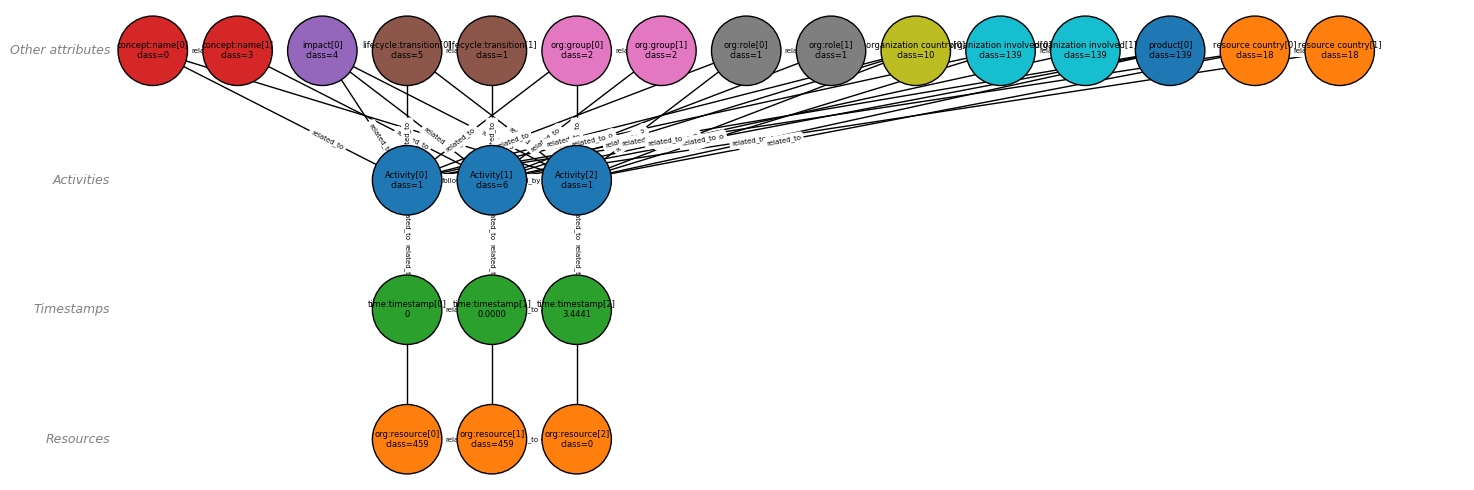

In [ ]:
drawer(newg)

In [ ]:
print(t)

{'Activity': tensor([[0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0.]]), 'org:resource': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        .

{'Activity': tensor([[  6.1015,   9.4044,   0.5051, -17.5261,   6.4445,   3.7881,   1.6995,
         -16.4853]]), 'org:resource': tensor([[ 2.2352e+01, -4.8736e+00, -1.0641e+01, -9.2050e+00, -3.5428e+01,
         -1.0586e+01, -7.4525e+00,  1.4112e-01, -1.0769e+01,  1.4963e+00,
         -6.1205e+00, -3.1525e+00, -3.6446e+01, -1.6563e+01, -7.9561e+00,
         -8.8110e+00, -8.7242e+00, -3.6744e+00, -9.1646e-01, -1.7230e+01,
          1.4578e-01, -4.9901e+00, -1.2211e+01, -1.2008e+01, -3.6433e+00,
         -1.5381e+00, -1.0807e+01, -1.6316e+00,  1.9284e+00, -3.6264e+01,
         -5.5545e+00, -7.1391e+00, -6.8191e+00, -2.8860e+00, -2.9367e+00,
         -5.7558e-01, -3.6065e+01, -8.9045e+00,  1.5433e+00,  4.8379e-01,
         -5.5335e+00, -5.0408e+00, -1.1471e+01, -1.0068e+01, -1.2726e+01,
         -4.9586e+00, -3.5715e+01, -1.1271e+01, -3.5800e+01, -1.6003e+01,
          1.2216e+00, -3.5591e+01, -3.6776e+01, -9.4880e+00, -1.0848e+01,
         -7.2671e+00, -1.0788e+01, -4.6774e+00,  5.5018e

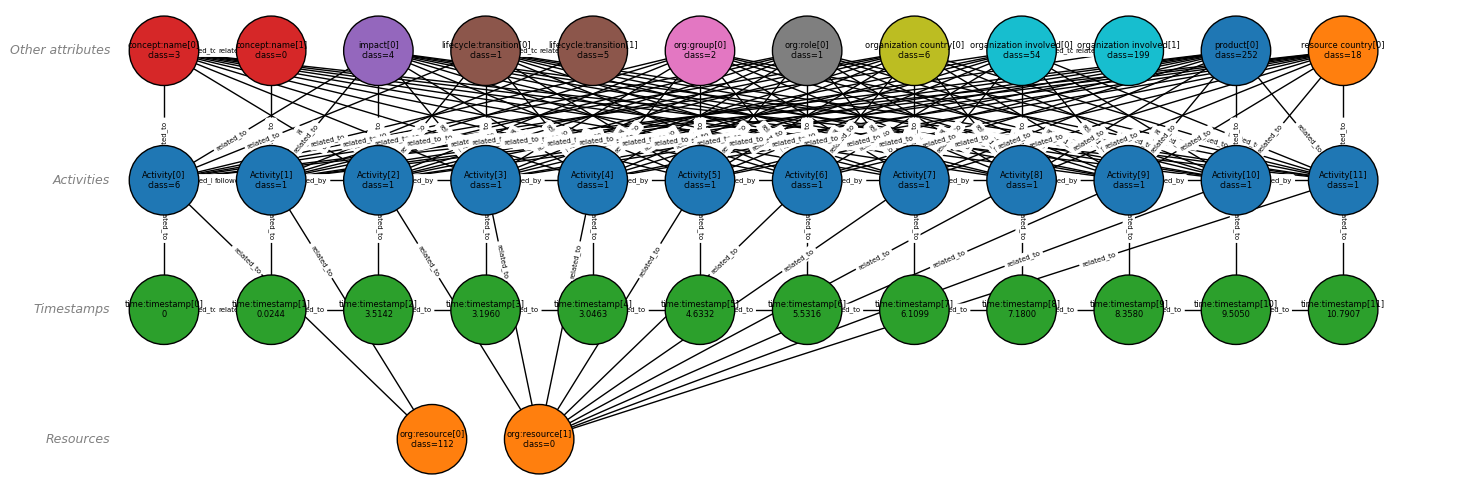

In [ ]:
for i in range(10):
  loader = DataLoader([g], batch_size=1)
  batch = next(iter(loader))  # ora batch[k].batch esiste

  net.eval()
  with torch.no_grad():
      out = net(batch)

  print(out)

  # Predictions extraction
  preds = {}

  # Categoriche → argmax → one-hot
  for k in outputcat:
      idx = torch.argmax(torch.softmax(out[k], dim=1), dim=1).item()
      one_hot = torch.zeros(1, outputcat[k])
      one_hot[0, idx] = 1.0
      preds[k] = one_hot
      if idx < len(list_unique[k]): # Check if idx is within the bounds of list_unique
          print(f"{k}: {list_unique[k][idx]}")
      else:
          print(f"{k}: <Unknown Category {idx}>") # Handle the extra category

  # Numeriche → valore diretto
  for k in outputreal:
      preds[k] = out[k].reshape(1, 1)
      print(f"{k}: {out[k].item():.4f}")

  g = append_predicted_event(g, out, outputcat, outputreal)

drawer(g)

In [ ]:
from torch_geometric.data import Batch
from tqdm import tqdm

def test_hgnn(net, output_cat, output_real, max_steps=20):
    END_ACTIVITY_IDX = output_cat["Activity"] - 1
    i = 0

    # TESTING LOOP
    net.eval()
    with torch.no_grad():
        for g, t in tqdm(X_TEST, desc="Testing"):
            # Loss preservation
            trace_logits_cat = {k: [] for k in output_cat}
            trace_preds_cat  = {k: [] for k in output_cat}
            trace_preds_real = {k: [] for k in output_real}

            for _ in range(max_steps):
                batch = Batch.from_data_list([g]).to(device)
                out   = net(batch)

                # just copying how loss was back in the test
                for k in output_cat:
                    trace_logits_cat[k].append(out[k])                      # [1, n_classes]
                    trace_preds_cat[k].append(torch.argmax(out[k], dim=1))  # [1]
                for k in output_real:
                    trace_preds_real[k].append(out[k].squeeze())            # real

                # Stop when END Activity
                if trace_preds_cat["Activity"][-1].item() == END_ACTIVITY_IDX:
                    break

In [ ]:
test_hgnn(net, outputcat, outputreal)

Testing:   1%|▏         | 2/139 [00:01<02:07,  1.07it/s]


KeyboardInterrupt: 

In [ ]:
# First graph dissection
g, t = X_TEST[3]
print(g)

HeteroData(
  Activity={ x=[2, 8] },
  org:resource={ x=[1, 586] },
  time:timestamp={ x=[2, 1] },
  concept:name={ x=[2, 5] },
  impact={ x=[1, 5] },
  lifecycle:transition={ x=[2, 8] },
  org:group={ x=[1, 16] },
  org:role={ x=[1, 30] },
  organization country={ x=[1, 18] },
  organization involved={ x=[2, 325] },
  product={ x=[1, 338] },
  resource country={ x=[1, 22] },
  (Activity, followed_by, Activity)={ edge_index=[2, 2] },
  (Activity, related_to, org:resource)={ edge_index=[2, 2] },
  (Activity, related_to, time:timestamp)={ edge_index=[2, 2] },
  (Activity, related_to, concept:name)={ edge_index=[2, 2] },
  (Activity, related_to, impact)={ edge_index=[2, 2] },
  (Activity, related_to, lifecycle:transition)={ edge_index=[2, 2] },
  (Activity, related_to, org:group)={ edge_index=[2, 2] },
  (Activity, related_to, org:role)={ edge_index=[2, 2] },
  (Activity, related_to, organization country)={ edge_index=[2, 2] },
  (Activity, related_to, organization involved)={ edge_index=

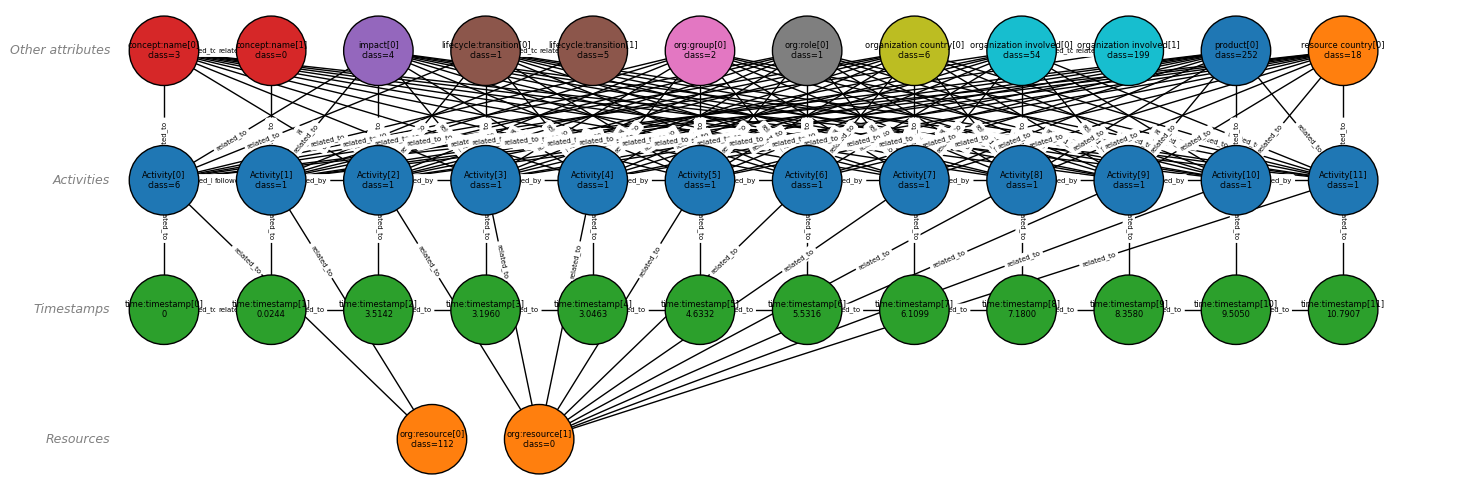

In [ ]:
drawer(g)

In [ ]:
print(t)

{'Activity': tensor([[0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0.]]), 'org:resource': tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

In [ ]:
tt= t["Activity"]
col_indices = tt.argmax(dim=1).tolist()

print(col_indices)

for idx in col_indices:
  if idx < len(list_unique["Activity"]): # Check if idx is within the bounds of list_unique
      print(f"Activity: {list_unique["Activity"][idx]}")
  else:
      print(f"Activity: END ({idx})>") # Handle the extra category